In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [4]:
df = pd.read_csv("/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [11]:
df.drop(columns= ['RowNumber','CustomerId','Surname'],inplace = True)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
# converting categorical col into numerical features (one hot encoding)
df = pd.get_dummies(df , columns = ['Geography','Gender'] ,drop_first = True )

In [14]:
df.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
5,645,44,8,113755.78,2,1,0,149756.71,1,False,True,True
6,822,50,7,0.00,2,1,1,10062.80,0,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,True,False,False
8,501,44,4,142051.07,2,0,1,74940.50,0,False,False,True
9,684,27,2,134603.88,1,1,1,71725.73,0,False,False,True


In [15]:
# scale the values
X = df.drop(columns = ['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [16]:
X 

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [17]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [18]:
X_train.shape

(8000, 11)

In [19]:
y_train.shape

(8000,)

In [20]:
#scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [23]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [41]:
# making sequential model
model = Sequential()
# dense = it creates dense layer & 3 = 3 perceptrons
model.add(Dense(11,activation = 'relu',input_dim = 11 )) # input layer
model.add(Dense(11,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid')) # output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()
# input layer = 11 parameters and 3 nodes and 3 biases = 11*3 + 3 = 36
#output layer = 3nodes , 1 output node and 1 bias = 3*1+1 = 4
#total parameters = 40


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# model compilation (used to descide which loss func ,optimizer for gradient des is going to use)
model.compile(loss= 'binary_crossentropy', optimizer = 'Adam',metrics = ['accuracy'])

In [67]:
history = model.fit(X_train_scaled, y_train,epochs = 100,validation_split = 0.2)
#validation split = if you have 1000 customer data, it trains 800 and tests on 200

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8763 - loss: 0.3066 - val_accuracy: 0.8519 - val_loss: 0.3509
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8752 - loss: 0.3060 - val_accuracy: 0.8587 - val_loss: 0.3505
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8755 - loss: 0.3063 - val_accuracy: 0.8544 - val_loss: 0.3503
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8756 - loss: 0.3066 - val_accuracy: 0.8512 - val_loss: 0.3519
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8734 - loss: 0.3065 - val_accuracy: 0.8575 - val_loss: 0.3542
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.3068 - val_accuracy: 0.8537 - val_loss: 0.3512
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8747 - loss: 0.3067 - val_accuracy: 0.8581 - val_loss: 0.3527
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8747 - loss: 0.3069 - val_accu

**training and validation dono ki accuracy increase honi chahiyee 
if only training datasets = accuracy increases and validation accuracy doesn't increases = overfitting**

In [69]:
model.layers[0].get_weights() # 1st layer weights and below that biases of it

[array([[ 0.32851946,  0.41025352,  0.07196309,  0.20932403,  0.17098905,
          0.05836195,  0.6266246 ,  0.21980536,  0.0495281 ,  0.38353243,
          0.17238343],
        [-0.20109484, -0.9812494 , -0.343903  , -0.30369872, -1.1689361 ,
          0.05036519,  0.5464389 ,  0.780763  , -0.73203063, -0.6958015 ,
         -0.07900164],
        [-0.02190475,  0.02805678, -0.48795724, -0.46136403,  0.07437313,
         -0.01577726,  0.00242953, -0.21076566, -0.23206837,  0.29148382,
         -0.08295907],
        [-0.22921304,  1.3002759 , -0.13802665, -0.27910396, -0.17592137,
         -0.6442354 ,  0.15460812,  0.0463583 ,  0.7800128 , -0.02249069,
          0.32712862],
        [-0.7605932 , -0.44947377,  0.28227144, -0.4017552 ,  0.21910736,
          1.3830521 ,  0.35026154,  0.43809402,  0.34458897,  0.9244388 ,
          1.4410136 ],
        [-0.00465019,  0.11138433, -0.5199582 , -0.11870001, -0.0117351 ,
          0.10559317, -0.01458713,  0.09127638,  0.21909073,  0.1714781

In [71]:
model.layers[1].get_weights() # weights of layer 2 and biases

[array([[ 0.12090231,  0.17462224,  0.6259568 ,  0.19051912,  0.10432351,
          0.37157935,  0.32079887, -0.42593104, -0.7115206 ,  0.35343507,
         -0.35529342],
        [-1.2648144 , -0.6937293 ,  0.68198705,  0.02233772,  0.24862376,
         -0.74689716,  0.21333076, -0.4242887 , -0.02657469, -0.3377142 ,
          0.22942539],
        [-0.9357403 ,  0.24166912, -0.1726315 ,  0.29047182, -0.18288335,
          0.0068066 , -0.33014178, -0.22472343, -0.7408113 ,  0.10336588,
          0.24461444],
        [ 0.60678405, -1.963527  ,  0.14039388,  0.76033366,  0.46274158,
          0.18783909, -0.32077956,  0.39319387, -0.5172874 ,  0.3440164 ,
          0.25308886],
        [ 0.03131231,  0.06261101, -1.2818944 , -0.38789195, -0.19351253,
         -0.9427807 ,  0.6711545 ,  0.99024594,  0.22130705,  0.17148905,
          0.49644744],
        [ 0.57853454, -0.02394258,  0.13304304,  0.09804326, -2.61482   ,
          0.13429356,  0.63081187,  0.10580419, -0.06330398, -1.4294556

In [72]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [73]:
#converting above output into threshold 
# if threshold < 0.5 = customer will not leave  and threshold > 0.5 = customer will leave
y_pred = np.where(y_log > 0.5,1,0)

In [79]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.857

In [80]:
import matplotlib.pyplot as plt

In [86]:
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

#Overfitting is usually when the training accuracy becomes much higher than the validation accuracy, for example:

#Training Accuracy   = 99%
#Validation Accuracy = 82%   ❌ Overfitting

0.8760937452316284
0.8525000214576721


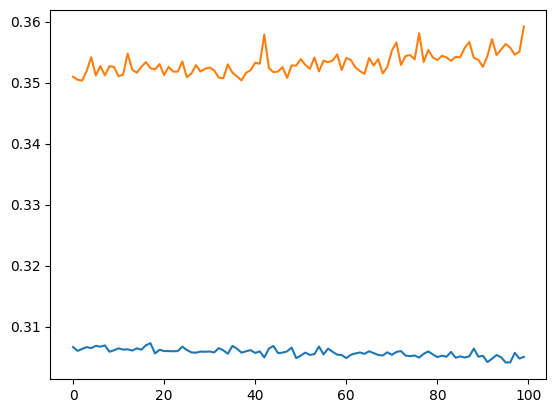

In [87]:
plt.plot(history.history['loss']) #tells about how loss decreased
plt.plot(history.history['val_loss']) # tells about how validation loss decrease

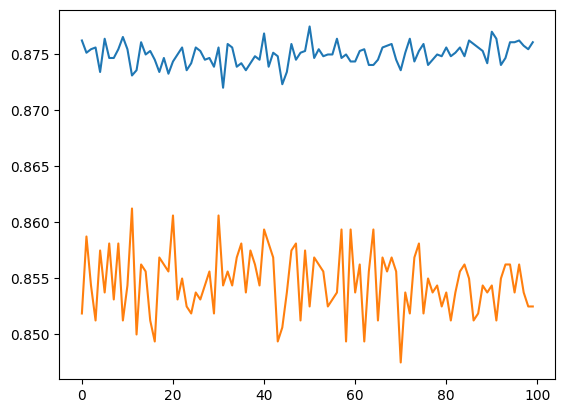

In [88]:
plt.plot(history.history['accuracy']) 
plt.plot(history.history['val_accuracy'])

**how can you improve accuracy**

Do 100 or 1000 epochs

In hidden layer use activation function = relu

In hidden layer increase no of nodes

Increase hidden layers 

